## Data vizualization
In this notebook, I will try toimplement meaningful visualization to better understand the structure of the data from patient 3390.
Inspired from subjects_loop.ipynb.
Patient 3390 is sub-01 

In [2]:
# Imports
import os
import numpy as np
import mne
from mne_bids import (
    find_matching_paths,
    read_raw_bids,
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mne.stats import permutation_cluster_test

from mne import Epochs
from mne.time_frequency import EpochsTFRArray

from mne.datasets import fetch_fsaverage

from pathlib import Path
import mne_bids
from mne_bids import BIDSPath

import matplotlib 
matplotlib.use('Agg') # or nbAgg
mne.viz.set_3d_backend('notebook')

Using notebook 3d backend.


In [3]:
#sample_path = "/media/RCPNAS/sEEG_MARS_Alison/"
subjects_dir = Path("/media/RCPNAS/sEEG_MARS_Alison")

In [4]:
# Your BIDS root
bids_root = subjects_dir # / "BIDS"

# FreeSurfer subjects directory - this is the key path!
fs_subjects_dir = Path("/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions") #bids_root / "sourcedata" / "reconstructions" / "PAT_3390" / "surf"

# Verify the PAT3390 subject exists
pat3390_path = fs_subjects_dir / "PAT_3390" #Path(subjects_dir) / "elec_recon" #bids_root / "sourcedata" / "reconstructions"
print(f"PAT3390 path exists: {pat3390_path.exists()}")
if pat3390_path.exists():
    print("Found FreeSurfer subject PAT3390 with directories:")
    print([d.name for d in pat3390_path.iterdir() if d.is_dir()])

# TODO: Now create mapping for all subjects
# Based on your folder structure, we need to map each BIDS subject to the correct patient
subject_to_fs = {
    "01": "PAT_3390",  #
}

# Process sub-01
subject = "01"
session = "retrieval"
task = "mars"
fs_subject = subject_to_fs[subject]

print(f"\nProcessing {subject} → FreeSurfer subject: {fs_subject}")
print(f"FreeSurfer directory: {fs_subjects_dir / fs_subject}")

# Create BIDS path
bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    datatype="ieeg",
    root=bids_root,
    suffix="ieeg",
    extension=".vhdr"
)

# Read data
print(f"\nLoading data from: {bids_path.fpath}")
raw = read_raw_bids(bids_path, verbose=False)

# Load bad annotations
bad_annotation_path = bids_root / f"sub-{subject}" / f"ses-{session}" / "ieeg" / f"sub-{subject}_ses-{session}_task-{task}_annot.csv"
if bad_annotation_path.exists():
    print("Bad annotation file found, adding to raw annotations")
    bad_annotations = mne.read_annotations(bad_annotation_path)
    #bad_annotations.set_orig_time(None)
    #bad_annotations.orig_time = raw.annotations.orig_time
    # Recreate annotations with matching orig_time
    bad_annotations = mne.Annotations(
        onset=bad_annotations.onset,
        duration=bad_annotations.duration,
        description=bad_annotations.description,
        orig_time=raw.annotations.orig_time
    )
    
    raw.set_annotations(raw.annotations + bad_annotations)
    print(f"Added {len(bad_annotations)} bad annotations")

# Now visualize electrodes on brain
print(f"\nCreating brain visualization for {fs_subject}")

# Create brain
brain = mne.viz.Brain(
    fs_subject,
    subjects_dir=str(fs_subjects_dir),  # This points to the freesurfer folder containing HL1996
    cortex="low_contrast",
    alpha=0.25,
    background="white",
    figure=1,
)

# Add electrodes if montage exists
if raw.get_montage() is not None:
    try:
        trans = mne.transforms.Transform('mri', 'head')  # Use identity transform for now
        brain.add_sensors(raw.info, trans=trans)
        print("Added electrodes to brain")
    except Exception as e:
        print(f"Could not add electrodes: {e}")
montage = raw.get_montage()
print(f"Montage exists: {montage is not None}")

if montage is None:
    print("\nNo montage found in raw data.")
    print("Looking for electrodes.tsv file...")
    
    # Look for electrodes.tsv
    electrodes_path = bids_root / f"sub-{subject}" / f"ses-{session}" / "ieeg" / f"sub-{subject}_ses-{session}_task-{task}_electrodes.tsv"
    print(f"Electrodes file exists: {electrodes_path.exists()}")
    
    if electrodes_path.exists():
        # Read electrodes.tsv
        electrodes_df = pd.read_csv(electrodes_path, sep='\t')
        print(f"\nElectrodes file contents:")
        print(f"Columns: {electrodes_df.columns.tolist()}")
        print(f"Number of electrodes: {len(electrodes_df)}")
        print("\nFirst few electrodes:")
        print(electrodes_df.head())
        
        # Check coordinate columns
        coord_cols = ['x', 'y', 'z']
        if all(col in electrodes_df.columns for col in coord_cols):
            print("\n✓ Found coordinate columns (x, y, z)")
            
            # Create montage
            montage = mne.channels.make_dig_montage(
                ch_pos=dict(zip(electrodes_df['name'], 
                               electrodes_df[coord_cols].values/1000)),
                coord_frame='mri'  # or 'head' - check which one
            )
            raw.set_montage(montage)
            print(f"✓ Created and set montage with {len(electrodes_df)} electrodes")
        else:
            print(f"✗ Expected coordinate columns not found. Available columns: {electrodes_df.columns.tolist()}")
    else:
        print("✗ No electrodes.tsv file found in BIDS directory")
        
        # Look for alternative coordinate files
        coord_files = list(Path(bids_root / f"sub-{subject}").rglob("*coord*"))
        print(f"Alternative coordinate files found: {coord_files}")
#brain.add_head(alpha=0.25, color="tan")

# Save images
output_dir = Path.cwd() / "figures"
output_dir.mkdir(exist_ok=True)

# Save different views
views = [
    ("lateral_right", dict(azimuth=90, elevation=90, distance=400)),
    ("lateral_left", dict(azimuth=-90, elevation=90, distance=400)),
    ("top", dict(azimuth=0, elevation=90, distance=400)),
    ("front", dict(azimuth=0, elevation=0, distance=400)),
    ("back", dict(azimuth=180, elevation=0, distance=400)),
]

for view_name, view_kwargs in views:
    brain.show_view(**view_kwargs)
    output_file = output_dir / f"{subject}_electrodes_{view_name}.png"
    brain.save_image(str(output_file))
    print(f"Saved: {output_file}")

brain.close()
print(f"\nAll images saved to {output_dir}")

PAT3390 path exists: True
Found FreeSurfer subject PAT3390 with directories:
['mri', 'tmp', 'stats', 'surf_old', 'elec_recon_BAD', 'touch', 'trash', 'surf', 'voxeloc', 'label', 'bem', 'mri_old', 'scripts', 'elec_recon', 'label_old', 'elec_recon_old']

Processing 01 → FreeSurfer subject: PAT_3390
FreeSurfer directory: /media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PAT_3390

Loading data from: /media/RCPNAS/sEEG_MARS_Alison/sub-01/ses-retrieval/ieeg/sub-01_ses-retrieval_task-mars_ieeg.vhdr


/tmp/ipykernel_1805435/344438347.py:42: RuntimeWarning: Did not find any electrodes.tsv associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*electrodes.tsv"
  raw = read_raw_bids(bids_path, verbose=False)
/tmp/ipykernel_1805435/344438347.py:42: RuntimeWarning: Did not find any coordsystem.json associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*coordsystem.json"
  raw = read_raw_bids(bids_path, verbose=False)


Bad annotation file found, adding to raw annotations
Added 5 bad annotations

Creating brain visualization for PAT_3390


2026-03-09 11:38:50.189 (   4.630s) [    7F44081E24C0]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Montage exists: False

No montage found in raw data.
Looking for electrodes.tsv file...
Electrodes file exists: False
✗ No electrodes.tsv file found in BIDS directory
Alternative coordinate files found: [PosixPath('/media/RCPNAS/sEEG_MARS_Alison/sub-01/ses-retrieval/ieeg/sub-3390_coordsystem.json')]
Saved: /home/aboschun/MIPlab-Project/figures/01_electrodes_lateral_right.png
Saved: /home/aboschun/MIPlab-Project/figures/01_electrodes_lateral_left.png
Saved: /home/aboschun/MIPlab-Project/figures/01_electrodes_top.png
Saved: /home/aboschun/MIPlab-Project/figures/01_electrodes_front.png
Saved: /home/aboschun/MIPlab-Project/figures/01_electrodes_back.png

All images saved to /home/aboschun/MIPlab-Project/figures


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import mne
from mne_bids import BIDSPath, read_raw_bids

# Your paths
bids_root = Path("/media/RCPNAS/sEEG_MARS_Alison")

# For PAT_3390, figure out which BIDS subject this is
# Based on your earlier mapping, PAT_3390 might be sub-03 or sub-04
# Let's check participants.tsv if it exists
participants_file = bids_root / "participants.tsv"
if participants_file.exists():
    participants = pd.read_csv(participants_file, sep='\t')
    print("Participants mapping:")
    print(participants)

# For now, let's assume PAT_3390 is sub-03 (adjust based on your mapping)
subject = "01"  # Change this based on actual mapping
session = "retrieval"
task = "mars"

# Load raw data to get channel names in TRC order
bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    datatype="ieeg",
    root=bids_root,
    suffix="ieeg",
    extension=".vhdr"
)

raw = read_raw_bids(bids_path, verbose=False)
trc_channel_names = raw.ch_names
#trc_channel_names = ['HAD1', 'HAD2', 'HAG1', 'HAG2', 'HPD1', 'HPD2', 'HPG1', 'HPG2']  
print(f"TRC channel names (first 10): {trc_channel_names[:10]}")
print(f"Total channels: {len(trc_channel_names)}")

# Path to electrode reconstruction files
elec_recon_path = bids_root / "sourcedata" / "reconstructions" / "PAT_3390" / "elec_recon"

coord_type = "LEPTO"  #     use LEPTO !!!!!
coord_file = elec_recon_path / f"PAT_3390.{coord_type}"

print(f"\nLoading coordinates from: {coord_file}")
print(f"File exists: {coord_file.exists()}")

if coord_file.exists():
    # Read the coordinate file
    # These are typically text files with coordinates in mm
    coords = []
    with open(coord_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#'):  # Skip empty lines and comments
                try:
                    # Parse x y z coordinates
                    parts = line.split()
                    if len(parts) >= 3:
                        x, y, z = float(parts[0]), float(parts[1]), float(parts[2])
                        coords.append([x, y, z])
                except:
                    continue
    
    coords = np.array(coords)
    print(f"Loaded {len(coords)} coordinates")
    
    # Also load electrode names if available
    names_file = elec_recon_path / "PAT_3390.electrodeNames"
    if names_file.exists():
        with open(names_file, 'r') as f:
            electrode_names = [line.strip() for line in f if line.strip() and not line.startswith('#')]
        print(f"Loaded {len(electrode_names)} electrode names")
    else:
        electrode_names = [f"ELEC{i+1:03d}" for i in range(len(coords))]
    
    # Check if number matches TRC channels
    print(f"\nCoordinate count: {len(coords)}")
    print(f"TRC channel count: {len(trc_channel_names)}")
    print(f"Electrode names count: {len(electrode_names)}")
    
    if len(coords) == len(trc_channel_names):
        print("✓ Coordinate count matches TRC channels - using as-is")
        montage_coords = coords
        montage_names = trc_channel_names
    else:
        print("⚠️  Count mismatch - need to map coordinates to TRC channels")
        
        # Create mapping dictionary
        coord_dict = dict(zip(electrode_names, coords))
        
        # Map to TRC order
        montage_coords = []
        montage_names = []
        
        for ch_name in trc_channel_names:
            # Try exact match
            #if ch_name not in ["HAD1", "HAD2", "HAG1", "HAG2", "HPD1", "HPD2", "HPG1", "HPG2"] :
            #    continue
            if ch_name in coord_dict:
                montage_coords.append(coord_dict[ch_name])
                montage_names.append(ch_name)
            else:
                # Try without spaces/special chars
                ch_clean = ch_name.replace(' ', '').replace('-', '').replace("'", "")
                found = False
                for coord_name in coord_dict.keys():
                    coord_clean = coord_name.replace(' ', '').replace('-', '').replace("'", "")
                    if ch_clean in coord_clean or coord_clean in ch_clean:
                        montage_coords.append(coord_dict[coord_name])
                        montage_names.append(ch_name)
                        print(f"  Matched {ch_name} to {coord_name}")
                        found = True
                        break
                
                if not found:
                    print(f"  Warning: No match for {ch_name}")
                    montage_coords.append([np.nan, np.nan, np.nan])
                    montage_names.append(ch_name)
        
        montage_coords = np.array(montage_coords)
    montage_coords = montage_coords / 1000  # Convert mm to m for MNE
    
    # Create montage
    montage = mne.channels.make_dig_montage(
        ch_pos=dict(zip(montage_names, montage_coords)),
        coord_frame='mri'  # These are in MRI coordinates
    )
    
    # Set montage to raw
    raw.set_montage(montage)
    print(f"\n✓ Created montage with {len(montage_names)} electrodes")
    
    # Verify first few electrodes
    print("\nFirst 5 electrode positions:")
    for i, ch_name in enumerate(montage_names[:5]):
        pos = montage.get_positions()['ch_pos'][ch_name]
        print(f"  {ch_name}: ({pos[0]}, {pos[1]:.1f}, {pos[2]:.1f})")
    
    # Save montage for future use
    montage_path = Path.cwd() / f"sub-{subject}_montage.fif"
    montage.save(montage_path, overwrite=True)
    print(f"Saved montage to {montage_path}")
    
    # Now you can get volume labels if FreeSurfer subject exists
    fs_subject = "PAT_3390"
    subjects_dir = bids_root / "sourcedata" / "reconstructions"
    
    aparcaseg_path = "/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PAT_3390/mri/aparc+aseg.mgz"

    if Path(aparcaseg_path).exists():
        try:
            labels, colors = mne.get_montage_volume_labels(
                montage,
                fs_subject,
                subjects_dir=str(subjects_dir),
                aseg="aparc+aseg"
            )
            
            # labels and colors are dicts keyed by channel name
            # Build DataFrame from the dicts directly
            results_df = pd.DataFrame({
                'channel': list(labels.keys()),
                'label': [labels[ch] for ch in labels.keys()],
                'color': [colors[ch] for ch in labels.keys()]
            })
            
            output_path = Path.cwd() / f"sub-{subject}_electrode_labels.csv"
            results_df.to_csv(output_path, index=False)
            print(f"Saved electrode labels to {output_path}")
            print(results_df.head())
            
        except Exception as e:
            print(f"Could not get volume labels: {e}")

Participants mapping:
  participant_id  age  sex  hand  weight  height
0         sub-01  NaN  NaN   NaN     NaN     NaN
1         sub-02  NaN  NaN   NaN     NaN     NaN
2         sub-03  NaN  NaN   NaN     NaN     NaN
3         sub-04  NaN  NaN   NaN     NaN     NaN
4         sub-06  NaN  NaN   NaN     NaN     NaN
TRC channel names (first 10): ['FOG1', 'FOG2', 'FOG3', 'FOG4', 'FOG5', 'FOG6', 'FOG7', 'FOG8', 'FOG9', 'FOG10']
Total channels: 120

Loading coordinates from: /media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PAT_3390/elec_recon/PAT_3390.LEPTO
File exists: True
Loaded 118 coordinates
Loaded 120 electrode names

Coordinate count: 118
TRC channel count: 120
Electrode names count: 120
⚠️  Count mismatch - need to map coordinates to TRC channels
  Matched FOG1 to FOG1 D L
  Matched FOG2 to FOG2 D L
  Matched FOG3 to FOG3 D L
  Matched FOG4 to FOG4 D L
  Matched FOG5 to FOG5 D L
  Matched FOG6 to FOG6 D L
  Matched FOG7 to FOG7 D L
  Matched FOG8 to FOG8 D L
  Matched FOG9

/tmp/ipykernel_1805435/68676815.py:35: RuntimeWarning: Did not find any electrodes.tsv associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*electrodes.tsv"
  raw = read_raw_bids(bids_path, verbose=False)
/tmp/ipykernel_1805435/68676815.py:35: RuntimeWarning: Did not find any coordsystem.json associated with sub-01_ses-retrieval_task-mars.

The search_str was "/media/RCPNAS/sEEG_MARS_Alison/sub-01/**/ieeg/sub-01_ses-retrieval*coordsystem.json"
  raw = read_raw_bids(bids_path, verbose=False)
/tmp/ipykernel_1805435/68676815.py:133: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  raw.set_montage(montage)
/tmp/ipykernel_1805435/68676815.py:133: RuntimeWarning: Not setting positions of 2 ecg/misc channels found in montage:
['photodiode', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst

Saved montage to /home/aboschun/MIPlab-Project/sub-01_montage.fif
Could not get volume labels: 'FOG1'


In [6]:
montage

<DigMontage | 0 extras (headshape), 0 HPIs, 0 fiducials, 120 channels>

In [7]:
montage.get_positions()

{'ch_pos': OrderedDict([('FOG1',
               array([-0.01426352,  0.03295186,  0.0331191 ])),
              ('FOG2', array([-0.01589528,  0.03342779,  0.03617865])),
              ('FOG3', array([-0.01752704,  0.03390372,  0.0392382 ])),
              ('FOG4', array([-0.0191588 ,  0.03437965,  0.04229775])),
              ('FOG5', array([-0.02079056,  0.03485558,  0.0453573 ])),
              ('FOG6', array([-0.02242232,  0.03533151,  0.04841685])),
              ('FOG7', array([-0.02405408,  0.03580744,  0.0514764 ])),
              ('FOG8', array([-0.02568584,  0.03628337,  0.05453595])),
              ('FOG9', array([-0.0273176 ,  0.0367593 ,  0.05759551])),
              ('FOG10', array([-0.02894936,  0.03723523,  0.06065505])),
              ('FOG11', array([-0.03 ,  0.01 ,  0.029])),
              ('FOG12', array([-0.02899034,  0.01085024,  0.03224155])),
              ('IAG1', array([-0.02798067,  0.01170049,  0.03548311])),
              ('IAG2', array([-0.02697101,  0.01255

In [8]:
aseg = "aparc+aseg"  # parcellation/anatomical segmentation atlas
path_atlas = "/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions"
#montage = raw.get_montage()

# Get volume labels for each electrode based on the montage and FreeSurfer subject
labels, colors = mne.get_montage_volume_labels(
    montage, "PAT_3390", subjects_dir=path_atlas, aseg=aseg
)
print(f"Labels: {labels}")

# separate by electrodes which have names like LAMY 1
electrodes = set(
    [
        "".join([lttr for lttr in ch_name if not lttr.isdigit() and lttr != " "])
        for ch_name in montage.ch_names
    ]
)
print(f"Electrodes in the dataset: {electrodes}")

# Define regions of interest (ROIs) to keep
regions_of_interest = {
    "ctx-rh-parahippocampal",
    "ctx-rh-fusiform",
    "Right-Hippocampus",
    "ctx-lh-parahippocampal",
    "ctx-lh-fusiform",
    "Left-Hippocampus",
    # add more as needed
}

# Get labels that correspond to the ROIs --> electrodes that are in the regions of interest
filtered_labels = {
    ch: region_list
    for ch, region_list in labels.items()
    if any(r in regions_of_interest for r in region_list)
}

print(f"Kept {len(filtered_labels)}/{len(labels)} electrodes")
for ch, regions in filtered_labels.items():
    print(f"  {ch}: {regions}")

# New set of electrodes that have labels in the ROIs
filtered_electrodes = set([ch.split(" ")[0] for ch in filtered_labels.keys()])

# Plot their ROIs
fig, ax = mne.viz.plot_channel_labels_circle(filtered_labels, colors, picks=list(filtered_electrodes))
fig.text(0.3, 0.9, "Anatomical Labels", color="white")
fig.savefig(f"figures/{subject}_allelec_labels.png", dpi=300)

Labels: OrderedDict({'FOG1': ['Left-Cerebral-White-Matter'], 'FOG2': ['Left-Cerebral-White-Matter', 'ctx-lh-lateralorbitofrontal'], 'FOG3': ['Left-Cerebral-White-Matter', 'ctx-lh-lateralorbitofrontal'], 'FOG4': ['Left-Cerebral-White-Matter'], 'FOG5': ['Left-Cerebral-White-Matter'], 'FOG6': ['Left-Cerebral-White-Matter'], 'FOG7': ['Left-Cerebral-White-Matter'], 'FOG8': ['Left-Cerebral-White-Matter'], 'FOG9': ['Left-Cerebral-White-Matter'], 'FOG10': ['Left-Cerebral-White-Matter', 'ctx-lh-rostralmiddlefrontal'], 'FOG11': ['Left-Cerebral-White-Matter', 'ctx-lh-insula'], 'FOG12': ['Left-Cerebral-White-Matter', 'ctx-lh-insula'], 'IAG1': ['Left-Cerebral-White-Matter'], 'IAG2': ['Left-Cerebral-White-Matter'], 'IAG3': ['Left-Cerebral-White-Matter', 'ctx-lh-insula'], 'IAG4': ['Left-Cerebral-White-Matter', 'ctx-lh-insula'], 'IAG5': ['Left-Cerebral-White-Matter', 'ctx-lh-insula'], 'IAG6': ['Left-Cerebral-White-Matter', 'ctx-lh-insula', 'ctx-lh-parstriangularis'], 'IAG7': ['Left-Cerebral-White-Matt

Let's separate the average evoked response for the 7 different conditions:

In [49]:
raw_filtered = raw.copy().pick_channels(filtered_electrodes)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


In [57]:
raw_filtered.annotations

<Annotations | 120 segments: 1 (20), 2 (20), 3 (15), 4 (15), 5 (15), 6 ...>

In [75]:
annot_df = raw_filtered.annotations.to_data_frame()

# Create event id from macthing description and condition
print(annot_df['description'])
print(annot_df['condition'])

event_id_for_events = {}
for desc, cond in zip(annot_df['description'], annot_df['condition']):
    if cond not in event_id_for_events:
        event_id_for_events[str(desc)] = int(desc)  # Assign a unique integer ID
print(f"Event ID mapping: {event_id_for_events}")

events, _ = mne.events_from_annotations(
    raw_filtered, 
    event_id={k: v for k, v in event_id_for_events.items()}
)

# Change events to correct conditions
event_id = {}
for desc, cond in zip(annot_df['description'], annot_df['condition']):
    if cond not in event_id:
        event_id[str(cond)] = int(desc)  # Assign a unique integer ID
print(f"Event ID mapping: {event_id}")

events


0      2
1      5
2      2
3      5
4      3
      ..
115    4
116    7
117    6
118    4
119    7
Name: description, Length: 120, dtype: str
0            Current
1              Futur
2            Current
3              Futur
4      Distant Futur
           ...      
115     Distant Past
116             Past
117            Never
118     Distant Past
119             Past
Name: condition, Length: 120, dtype: str
Event ID mapping: {'2': 2, '5': 5, '3': 3, '6': 6, '1': 1, '7': 7, '4': 4}
Used Annotations descriptions: [np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7')]
Event ID mapping: {'Current': 2, 'Futur': 5, 'Distant Futur': 3, 'Never': 6, 'Always': 1, 'Past': 7, 'Distant Past': 4}


array([[ 108096,       0,       2],
       [ 121613,       0,       5],
       [ 134784,       0,       2],
       [ 146866,       0,       5],
       [ 161032,       0,       3],
       [ 187863,       0,       3],
       [ 199945,       0,       6],
       [ 211346,       0,       2],
       [ 220392,       0,       6],
       [ 228990,       0,       5],
       [ 244866,       0,       3],
       [ 275449,       0,       6],
       [ 284427,       0,       3],
       [ 300097,       0,       2],
       [ 313062,       0,       6],
       [ 320676,       0,       1],
       [ 332249,       0,       3],
       [ 352250,       0,       1],
       [ 362900,       0,       1],
       [ 371807,       0,       3],
       [ 386214,       0,       3],
       [ 400958,       0,       5],
       [ 416351,       0,       5],
       [ 427889,       0,       1],
       [ 436558,       0,       2],
       [ 448301,       0,       3],
       [ 459802,       0,       3],
       [ 474378,       0,   

In [78]:
# Get averages for each condition
epochs = mne.Epochs(raw_filtered, events=events, event_id=event_id, detrend=1, baseline=None)
cond_current = epochs['Current'].average()
cond_never = epochs['Never'].average()
cond_always = epochs['Always'].average()
cond_past = epochs['Past'].average()
cond_futur = epochs['Futur'].average()
cond_distant_past = epochs['Distant Past'].average()
cond_distant_futur = epochs['Distant Futur'].average()

Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated


Visualize electrode placement :

In [79]:
# TODO: clean the different picks and keep a clean pipeline
picks = [
    ii
    for ii, ch_name in enumerate(montage.ch_names)
    if any([elec in ch_name for elec in filtered_electrodes])
]
print(picks)

""" labels = (
    "ctx-rh-parahippocampal",
    "ctx-rh-fusiform",
    'Right-Inf-Lat-Vent', 
    'Right-Hippocampus'
) """

trans = mne.transforms.Transform('mri', 'head') 
fig = mne.viz.plot_alignment(
    epochs.info,
    trans=trans,         
    subject=fs_subject,
    subjects_dir=subjects_dir,
    surfaces=[],
    coord_frame="mri",
)

picks_hip = mne.pick_channels(epochs.info['ch_names'], include=filtered_electrodes)

brain = mne.viz.Brain(
    fs_subject,
    alpha=0.1,
    cortex="low_contrast",
    subjects_dir=str(fs_subjects_dir), 
    units="m",
    figure=fig,
)
brain.add_volume_labels(aseg="aparc+aseg", labels=regions_of_interest)

brain.show_view(azimuth=120, elevation=90, distance=0.5, )
brain.save_image("figures/regions_mydata01.png")

brain.show_view(azimuth=60, elevation=90, distance=0.5)
brain.save_image("figures/regions_mydata02.png")

brain.show_view(azimuth=60, elevation=45, distance=0.5)
brain.save_image("figures/regions_mydata03.png")

brain.show_view(azimuth=0, elevation=45, distance=0.5)
brain.save_image("figures/regions_mydata04.png")

brain.show_view(azimuth=30, elevation=45, distance=0.5)
brain.save_image("figures/regions_mydata05.png")

[74, 75, 76, 83, 84, 85, 86, 87, 94, 95, 96, 97, 99, 105, 106, 107, 110]
Channel types::	seeg: 6


A view with name (P_0x7f4338fdc550_8) is already registered
 => returning previous one


    Smoothing by a factor of 0.9


Nice! We see that the electrodes are only located in the left hemisphere (as concluded from the labels) and the electrodes labeled as being in the hippocampus region are where they are supposed to be. We can now continue with more advanced visualizations: 

For the next video, I had to add the T1.gz from the old mri folder and lh.white and rh.white from the old surf file.
Unfortunately, I think that these do not fit with the new corrected data (to be continued).

    Reading a source space...
    [done]
    1 source spaces read


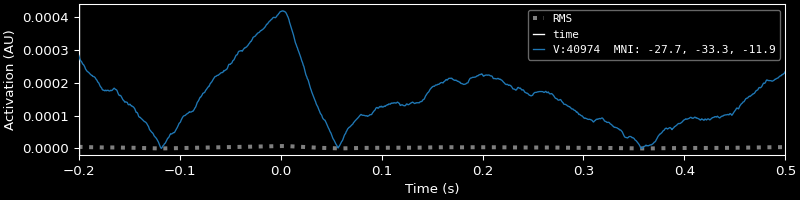

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


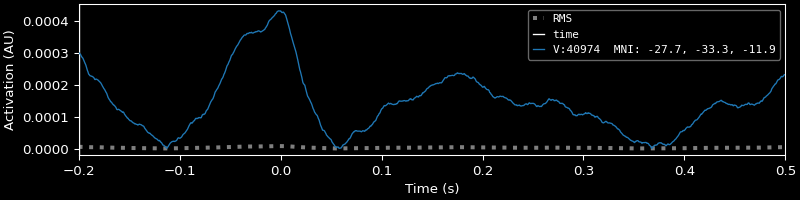

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


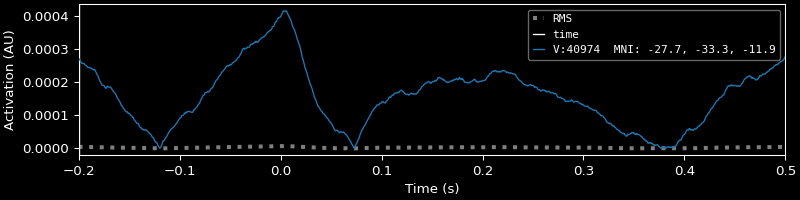

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


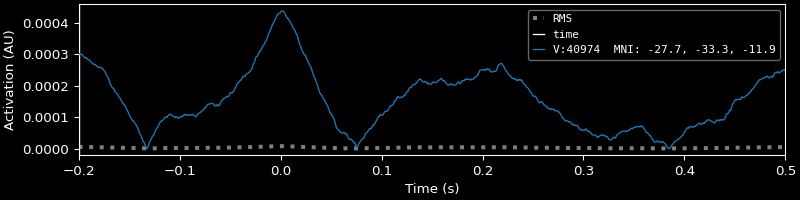

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


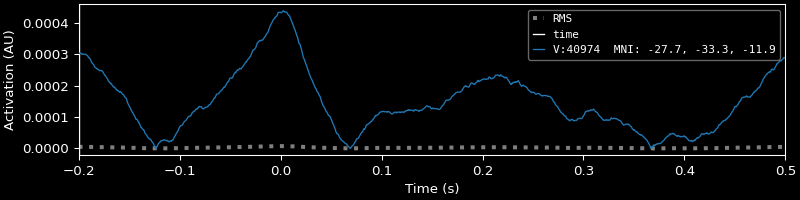

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


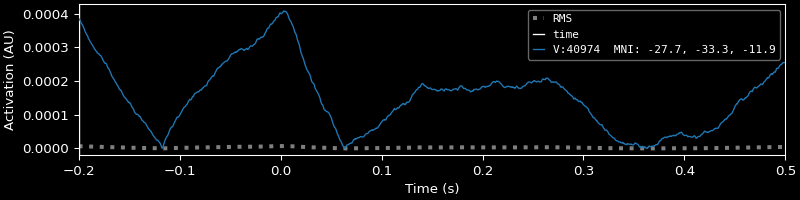

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


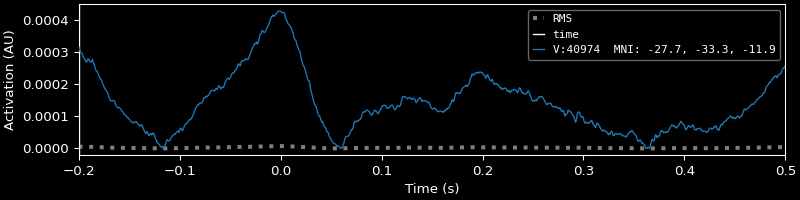

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [ ]:
fname_src = fs_subjects_dir / "PAT_3390" / "bem" / "PAT_3390-vol-5-src.fif"

if not fname_src.exists():
    vol_src = mne.setup_volume_source_space(
        fs_subject,
        pos=5.0,
        subjects_dir=str(fs_subjects_dir),
        verbose=True,
    )
    mne.write_source_spaces(fname_src, vol_src, overwrite=True)
else:
    vol_src = mne.read_source_spaces(fname_src)

evoked = [cond_current, cond_never, cond_always, cond_past, cond_futur, cond_distant_past, cond_distant_futur]  # List of evoked objects for each condition
i = 1
# TODO: zoom the video on the hippocampus
for cond in evoked:
    #cond.pick(picks_hip)  # Keep only the channels of interest
    stc = mne.stc_near_sensors(
        cond,
        trans,
        fs_subject,
        subjects_dir=subjects_dir,
        src=vol_src,
        surface=None,
        verbose="error",
    )
    stc = abs(stc)  # just look at magnitude
    clim = dict(kind="value", lims=np.percentile(abs(cond.data), [10, 50, 75]))
    brain = stc.plot_3d(
        src=vol_src,
        subjects_dir=subjects_dir,
        view_layout="horizontal",
        views=["axial", "coronal", "sagittal"],
        size=(800, 300),
        show_traces=0.4,
        clim=clim,
        add_data_kwargs=dict(colorbar_kwargs=dict(label_font_size=8)),
    )

    brain.save_movie(time_dilation=3, interpolation='linear', framerate=5, time_viewer=True, filename=f'PAT_3390_ieeg_{i}_movie.mp4')
    i += 1